<a href="https://colab.research.google.com/github/isabelcordova-hash/Mineria-de-Datos-/blob/main/LAB06/LAB_S06_MDD_ICORDOVA_2026_01_Heart_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔬 **LABORATORIO N° 06 — Minería de Datos**
## **k-NN y Regresión Logística — Dataset Heart Disease (UCI)**

| Campo | Detalle |
|---|---|
| **Institución** | TECSUP — Pasión por la Tecnología |
| **Curso** | Minería de Datos — C64893 |
| **Semana** | 6 |
| **Docente** | Pilar Rocío Sayán Mejía |
| **Alumna** | Isabel Lucero Cordova Agurto|
| **Semestre** | 2026-I |


---
### 📋 **Instrucciones generales**
- Ejecuta **todas** las celdas de código en orden.
- Responde las preguntas en las celdas de texto (Markdown) asignadas.
- **Nuevo dataset:** En este laboratorio trabajamos con el dataset **Heart Disease (UCI)**.
- Al finalizar, descarga el notebook (.ipynb) con todas las celdas ejecutadas.

### 📚 **Referencias**
- Gironés Roig, J. et al. (2017). *Minería de datos: modelos y algoritmos*. Editorial UOC. Cap. 10.
- James, G. et al. (2023). *An Introduction to Statistical Learning* (2.ª ed.). Springer. Cap. 4.
- Géron, A. (2022). *Hands-On Machine Learning* (3.ª ed.). O'Reilly Media. Cap. 4.
- Burkov, A. (2019). *The Hundred-Page Machine Learning Book*. Cap. 3.

---
# **ACTIVIDAD 1: Revisión de Conceptos — k-NN y Regresión Logística**

Complete la tabla con **definiciones propias**. No copie textualmente de los materiales.

| N° | Concepto | Definición |
|:---:|---|---|
| 1 | k-Nearest Neighbors (k-NN) | |
| 2 | Lazy learner vs. Eager learner | |
| 3 | Valor de k en k-NN | |
| 4 | Efecto de k pequeño vs. k grande | |
| 5 | ¿Por qué normalizar antes de k-NN? | |
| 6 | Regresión logística (qué predice) | |
| 7 | Función sigmoide | |
| 8 | Coeficientes de regresión logística | |
| 9 | Odds ratio (interpretación) | |
| 10 | Regularización L1 (Lasso) vs. L2 (Ridge) | |
| 11 | Diferencia principal entre k-NN y Reg. Logística | |
| 12 | ¿Cuándo elegirías k-NN sobre Reg. Logística? | |

---
# **ACTIVIDAD 2: Desarrollo Práctico — Clasificación con k-NN y Regresión Logística**

En esta actividad aplicarás los dos primeros algoritmos de clasificación del curso al dataset **Heart Disease (UCI)**.
Seguirás el pipeline completo: carga → exploración → preparación → modelado → evaluación → comparación.

> *Ref: Gironés Roig, J. et al. (2017). Minería de datos. Editorial UOC. Cap. 10.*

---
## 🔹 **Paso 1: Carga y exploración del dataset Heart Disease**

### **¿Qué haremos?**
Cargaremos el dataset y entenderemos su estructura. Este paso es equivalente a las **Fases 1 y 2 de CRISP-DM** (comprensión del negocio y de los datos).

### **¿Por qué es importante?**
Antes de aplicar cualquier algoritmo, debemos conocer los datos: cuántos registros hay, si existen valores nulos, y cómo está distribuida la variable objetivo.

*Ref: James, G. et al. (2023). An Introduction to Statistical Learning. Cap. 4.*

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score, precision_score,
                             recall_score, classification_report, confusion_matrix, roc_curve)

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

# ==========================================
# CARGAR DATASET HEART DISEASE (UCI)
# ==========================================
url = 'https://raw.githubusercontent.com/sharmaroshan/Heart-UCI-Dataset/master/heart.csv'
df = pd.read_csv(url)

print('=' * 60)
print('DATASET: HEART DISEASE (UCI)')
print('=' * 60)
print(f'Dimensiones: {df.shape[0]} pacientes × {df.shape[1]} variables')
print(f'Valores nulos totales: {df.isnull().sum().sum()}')
print(f'\nVariable objetivo (target):')
print(df['target'].value_counts())
print(f'\n  0 = Sin enfermedad: {(df["target"]==0).sum()} ({(df["target"]==0).mean()*100:.1f}%)')
print(f'  1 = Con enfermedad: {(df["target"]==1).sum()} ({(df["target"]==1).mean()*100:.1f}%)')
print(f'\nPrimeras filas:')
df.head()

DATASET: HEART DISEASE (UCI)
Dimensiones: 303 pacientes × 14 variables
Valores nulos totales: 0

Variable objetivo (target):
target
1    165
0    138
Name: count, dtype: int64

  0 = Sin enfermedad: 138 (45.5%)
  1 = Con enfermedad: 165 (54.5%)

Primeras filas:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


### 📌 Diccionario de variables clínicas
Es fundamental entender qué mide cada variable antes de modelar. Aquí tienes la descripción clínica:

| Variable | Descripción clínica | Tipo |
|---|---|---|
| `age` | Edad del paciente en años | Continua |
| `sex` | Sexo biológico (1=masculino, 0=femenino) | Binaria |
| `cp` | Tipo de dolor torácico: 0=asintomático, 1=angina típica, 2=angina atípica, 3=no anginoso | Categórica ordinal |
| `trestbps` | Presión arterial en reposo (mm Hg) — valores normales: 90–120 | Continua |
| `chol` | Colesterol sérico (mg/dl) — valores normales: <200 | Continua |
| `fbs` | Glucemia en ayunas > 120 mg/dl (1=sí, 0=no) — indicador de diabetes | Binaria |
| `restecg` | Resultado del electrocardiograma en reposo (0=normal, 1=anormalidad ST-T, 2=hipertrofia ventricular) | Categórica |
| `thalach` | Frecuencia cardíaca máxima alcanzada durante prueba de esfuerzo | Continua |
| `exang` | Angina inducida por ejercicio (1=sí, 0=no) — dolor en el pecho al hacer ejercicio | Binaria |
| `oldpeak` | Depresión del segmento ST inducida por ejercicio — mide daño cardíaco | Continua |
| `slope` | Pendiente del segmento ST durante ejercicio (0=descendente, 1=plano, 2=ascendente) | Categórica |
| `ca` | Número de vasos principales coloreados por fluoroscopía (0–4) | Discreta |
| `thal` | Tipo de talasemia: 0=normal, 1=defecto fijo, 2=defecto reversible, 3=talasemia | Categórica |

### ✏️ **Pregunta 1**
**¿Cuántos pacientes tiene el dataset? ¿Está balanceado (proporción de enfermos vs. sanos)? ¿Cómo se compara con el desbalance del dataset Telco Churn de semanas anteriores (~26.5% churn)?**

***Respuesta:***

*El dataset tiene `303` pacientes. En cuanto al balance, la proporción es de `165` pacientes (`54.5%`) con enfermedad y `138` pacientes (`45.5%`) sin enfermedad. Esto indica que el dataset está razonablemente balanceado, ya que las clases están distribuidas de forma equitativa (aproximadamente `50/50`).*

*En comparación con el dataset `Telco Churn`, que tenía un desbalance considerable con solo un `~26.5%` de `churn` (clientes que se van), el dataset `Heart Disease` está mucho más balanceado. Esta distribución más equitativa de la variable objetivo es beneficiosa para el entrenamiento de modelos de clasificación, ya que evita que el modelo se incline excesivamente hacia la clase mayoritaria.*

---
## 🔹 **Paso 2: Análisis exploratorio — Correlaciones clínicas**

### **¿Qué haremos?**
Calcularemos la correlación de cada variable con la enfermedad cardíaca para identificar los **factores de riesgo más relevantes**.

### **¿Por qué?**
La correlación nos da una primera pista de qué variables podrían ser útiles para el modelo. Sin embargo, correlación NO implica causalidad: una variable con alta correlación no necesariamente *causa* la enfermedad.

*Ref: Géron, A. (2022). Hands-On Machine Learning. Cap. 4.*

ESTADÍSTICAS DESCRIPTIVAS:
          age     sex      cp  trestbps    chol     fbs  restecg  thalach  \
count  303.00  303.00  303.00    303.00  303.00  303.00   303.00   303.00   
mean    54.37    0.68    0.97    131.62  246.26    0.15     0.53   149.65   
std      9.08    0.47    1.03     17.54   51.83    0.36     0.53    22.91   
min     29.00    0.00    0.00     94.00  126.00    0.00     0.00    71.00   
25%     47.50    0.00    0.00    120.00  211.00    0.00     0.00   133.50   
50%     55.00    1.00    1.00    130.00  240.00    0.00     1.00   153.00   
75%     61.00    1.00    2.00    140.00  274.50    0.00     1.00   166.00   
max     77.00    1.00    3.00    200.00  564.00    1.00     2.00   202.00   

        exang  oldpeak   slope      ca    thal  target  
count  303.00   303.00  303.00  303.00  303.00  303.00  
mean     0.33     1.04    1.40    0.73    2.31    0.54  
std      0.47     1.16    0.62    1.02    0.61    0.50  
min      0.00     0.00    0.00    0.00    0.00    0

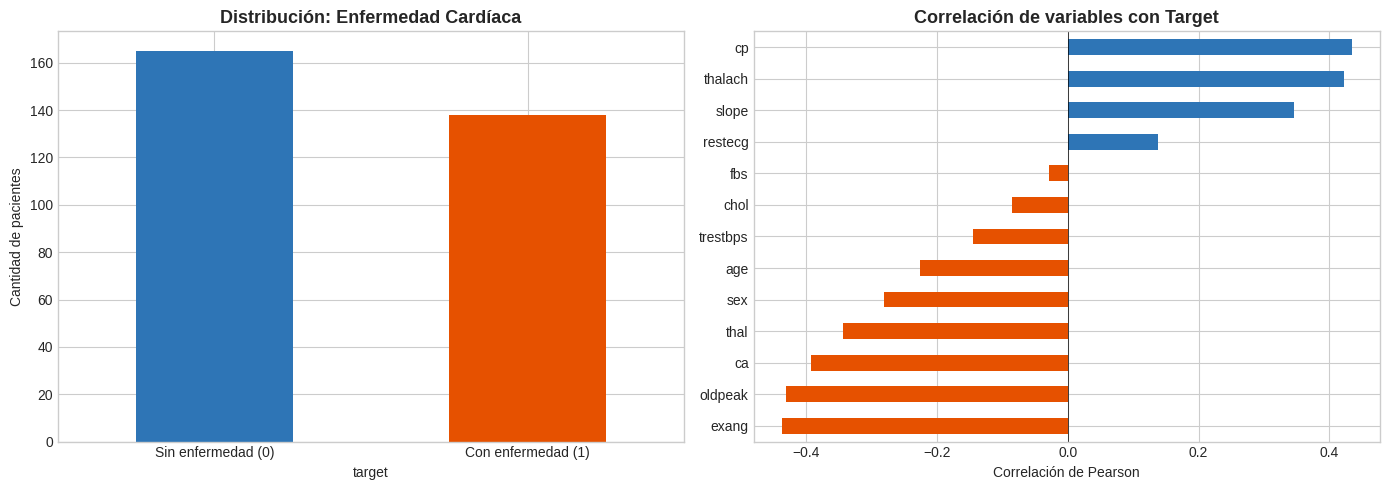


INTERPRETACIÓN DE CORRELACIONES:
  Correlación positiva (+) → a mayor valor, mayor riesgo de enfermedad
  Correlación negativa (−) → a mayor valor, menor riesgo de enfermedad

TOP 5 factores más correlacionados:
  exang         r = -0.437  → ↓ riesgo
  cp            r = +0.434  → ↑ riesgo
  oldpeak       r = -0.431  → ↓ riesgo
  thalach       r = +0.422  → ↑ riesgo
  ca            r = -0.392  → ↓ riesgo


In [ ]:
# Estadísticas descriptivas
print('ESTADÍSTICAS DESCRIPTIVAS:')
print(df.describe().round(2))

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Distribución de target
df['target'].value_counts().plot(kind='bar', color=['#2E75B6', '#E65100'], ax=axes[0])
axes[0].set_title('Distribución: Enfermedad Cardíaca', fontsize=13, fontweight='bold')
axes[0].set_xticklabels(['Sin enfermedad (0)', 'Con enfermedad (1)'], rotation=0)
axes[0].set_ylabel('Cantidad de pacientes')

# Gráfico 2: Correlación con target
correlations = df.corr()['target'].drop('target').sort_values()
colors_corr = ['#E65100' if v < 0 else '#2E75B6' for v in correlations]
correlations.plot(kind='barh', color=colors_corr, ax=axes[1])
axes[1].set_title('Correlación de variables con Target', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Correlación de Pearson')
axes[1].axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

# Interpretación automática
print('\nINTERPRETACIÓN DE CORRELACIONES:')
print('  Correlación positiva (+) → a mayor valor, mayor riesgo de enfermedad')
print('  Correlación negativa (−) → a mayor valor, menor riesgo de enfermedad')
print('\nTOP 5 factores más correlacionados:')
top_corr = correlations.abs().sort_values(ascending=False).head(5)
for var, val in top_corr.items():
    signo = '↑ riesgo' if correlations[var] > 0 else '↓ riesgo'
    print(f'  {var:12s}  r = {correlations[var]:+.3f}  → {signo}')

### ✏️ **Pregunta 2**
**¿Cuáles son las 3 variables con mayor correlación (positiva o negativa) con la enfermedad? ¿Tienen sentido clínico? Por ejemplo, ¿es lógico que `thalach` (frecuencia cardíaca máxima) tenga correlación positiva con la enfermedad?**

***Respuesta:***

*Las variables con mayor correlación absoluta con la enfermedad son `exang` (`r = -0.437`), `cp` (`r = +0.434`) y `oldpeak` (`r = -0.431`).*

* `exang` muestra correlación negativa: a mayor presencia de angina inducida por ejercicio, menor riesgo según el modelo. Esto resulta contraintuitivo, pues clínicamente la angina de esfuerzo suele ser un indicador de enfermedad cardíaca.*

* `cp` tiene correlación positiva: valores más altos de tipo de dolor torácico se asocian a mayor riesgo. Esto tiene sentido si la codificación de `cp` asigna valores altos a dolores de característica isquémica.*

* `oldpeak` también muestra correlación negativa: mayor depresión del segmento ST se relaciona con menor riesgo, lo cual es difícil de justificar clínicamente, ya que este hallazgo electrocardiográfico es un marcador clásico de isquemia.*

* Sobre `thalach` (`r = +0.422`): la correlación positiva indica que una frecuencia cardíaca máxima más alta se asocia a mayor probabilidad de enfermedad en este dataset. Aunque en población general una buena capacidad aeróbica suele ser protectora, en este contexto de pacientes con sospecha cardíaca podría reflejar mecanismos compensatorios (ej. taquicardia por menor reserva ventricular). Como siempre, correlación no implica causalidad.*

---
## 🔹 **Paso 3: Preparación de datos — Estandarización**

### **¿Qué haremos?**
Dividiremos los datos en train/test y aplicaremos **estandarización** (media=0, desviación=1).

### **¿Por qué?**
- **k-NN calcula distancias** entre puntos. Si una variable tiene rango [0, 500] (colesterol) y otra [0, 1] (sexo), la primera dominaría completamente las distancias. La estandarización pone todas las variables en la misma escala.
- **Regresión Logística** converge más rápido con datos estandarizados, aunque no es estrictamente obligatorio.
- Usamos `scaler.transform()` en test (NO `fit_transform`) para **evitar Data Leakage**: el test no debe influir en los parámetros de transformación.

*Ref: Géron, A. (2022). Hands-On Machine Learning. Cap. 4.*

In [ ]:
# Separar features y target
X = df.drop('target', axis=1)
y = df['target']

print(f'Features (X): {X.shape[1]} variables — {X.columns.tolist()}')
print(f'Target  (y):  distribución → {dict(y.value_counts())}')

# División train/test estratificada (70/30)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print(f'\nTrain: {X_train.shape[0]} pacientes ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Test:  {X_test.shape[0]} pacientes ({X_test.shape[0]/len(X)*100:.0f}%)')
print(f'Distribución en train: {dict(y_train.value_counts())}')
print(f'Distribución en test:  {dict(y_test.value_counts())}')

# Estandarización
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # Aprende media/std de train
X_test_scaled = scaler.transform(X_test)          # Aplica los mismos parámetros

print(f'\n✅ Estandarización aplicada correctamente')
print(f'   Media X_train_scaled ≈ 0: {X_train_scaled.mean():.6f}')
print(f'   Std  X_train_scaled ≈ 1:  {X_train_scaled.std():.6f}')
print(f'\n⚠️ Nota: scaler.transform() en test → evita Data Leakage')

Features (X): 13 variables — ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
Target  (y):  distribución → {1: np.int64(165), 0: np.int64(138)}

Train: 212 pacientes (70%)
Test:  91 pacientes (30%)
Distribución en train: {1: np.int64(115), 0: np.int64(97)}
Distribución en test:  {1: np.int64(50), 0: np.int64(41)}

✅ Estandarización aplicada correctamente
   Media X_train_scaled ≈ 0: -0.000000
   Std  X_train_scaled ≈ 1:  1.000000

⚠️ Nota: scaler.transform() en test → evita Data Leakage


### ✏️ **Pregunta 3**
**¿Por qué usamos `scaler.transform()` en test en lugar de `scaler.fit_transform()`? ¿Qué pasaría si un paciente nuevo llega al hospital — debemos re-calcular la estandarización o usar los parámetros del entrenamiento?**

***Respuesta:***

*Usamos `scaler.transform()` en el conjunto de test para evitar *data leakage*. Si aplicáramos `fit_transform()` sobre los datos de test, el escalador calcularía media y desviación estándar incluyendo información que el modelo no debería "ver" durante el entrenamiento, contaminando la evaluación.*

*El flujo correcto es: `fit_transform()` solo sobre `X_train` para que el escalador aprenda los parámetros de la distribución de entrenamiento, y luego `transform()` sobre `X_test` (y cualquier dato futuro) usando esos mismos parámetros. Así garantizamos que la transformación sea consistente y que el test simule datos realmente no vistos.*

*Si llega un paciente nuevo al hospital, aplicamos `scaler.transform()` con los parámetros guardados del entrenamiento original. No recalculamos la estandarización: el modelo fue entrenado bajo una escala específica, y alterar esa escala con datos nuevos generaría predicciones inconsistentes. En producción, el `scaler` se guarda junto al modelo y se reutiliza tal cual.*

---
## 🔹 **Paso 4: k-NN — Búsqueda del k óptimo**

### **¿Qué haremos?**
Probaremos diferentes valores de k (1, 3, 5, ..., 29) y usaremos **validación cruzada** para encontrar el mejor.

### **¿Por qué validación cruzada y no simplemente evaluar en test?**
Si usáramos el test set para elegir k, estaríamos **contaminando** nuestra evaluación final. La validación cruzada divide el train en 5 partes y rota cuál se usa como validación, dando una estimación más robusta sin tocar el test.

### **¿Qué esperar?**
- **k muy pequeño (1, 3):** el modelo memoriza el ruido de los datos → **overfitting** (buen score en train, malo en datos nuevos)
- **k muy grande (25, 29):** el modelo se vuelve demasiado simple, ignora patrones locales → **underfitting**
- **k óptimo:** el punto intermedio donde el modelo generaliza mejor

*Ref: Gironés Roig, J. et al. (2017). Minería de datos. Editorial UOC. Cap. 10.*

Evaluando k-NN para cada valor de k...
  k= 1: F1=0.8535 ± 0.0272  |  Acc=0.8351
  k= 3: F1=0.8366 ± 0.0390  |  Acc=0.8208
  k= 5: F1=0.8546 ± 0.0445  |  Acc=0.8353
  k= 7: F1=0.8632 ± 0.0340  |  Acc=0.8447
  k= 9: F1=0.8626 ± 0.0465  |  Acc=0.8449
  k=11: F1=0.8632 ± 0.0420  |  Acc=0.8447
  k=13: F1=0.8585 ± 0.0569  |  Acc=0.8355
  k=15: F1=0.8482 ± 0.0655  |  Acc=0.8215
  k=17: F1=0.8521 ± 0.0572  |  Acc=0.8261
  k=19: F1=0.8567 ± 0.0536  |  Acc=0.8309
  k=21: F1=0.8562 ± 0.0505  |  Acc=0.8308
  k=23: F1=0.8568 ± 0.0590  |  Acc=0.8309
  k=25: F1=0.8595 ± 0.0453  |  Acc=0.8354
  k=27: F1=0.8612 ± 0.0429  |  Acc=0.8354
  k=29: F1=0.8629 ± 0.0478  |  Acc=0.8355


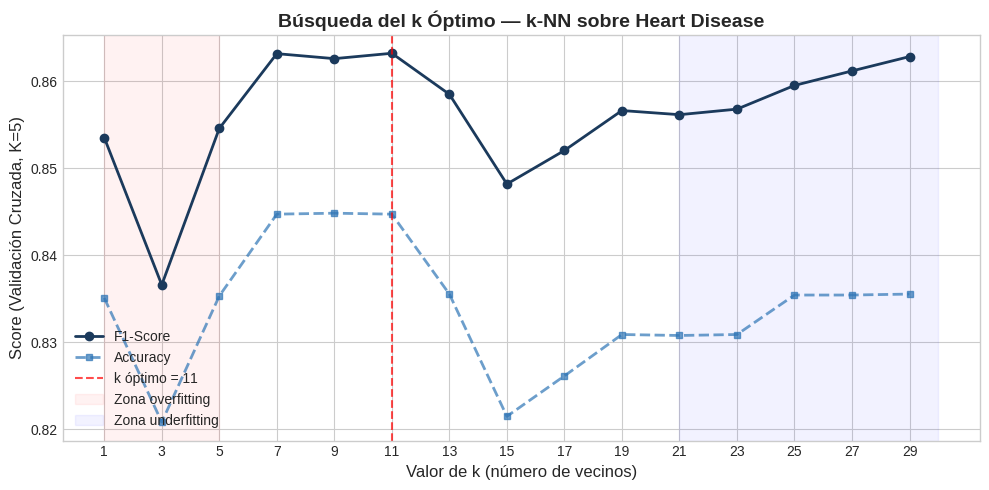


✅ Mejor k = 11  →  F1-Score = 0.8632


In [ ]:
# Búsqueda del k óptimo con validación cruzada 5-Fold
k_range = range(1, 31, 2)  # Solo impares (evita empates en votación)
cv_scores_f1 = []
cv_scores_acc = []

print('Evaluando k-NN para cada valor de k...')
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores_f1 = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='f1')
    scores_acc = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='accuracy')
    cv_scores_f1.append(scores_f1.mean())
    cv_scores_acc.append(scores_acc.mean())
    print(f'  k={k:2d}: F1={scores_f1.mean():.4f} ± {scores_f1.std():.4f}  |  Acc={scores_acc.mean():.4f}')

# Gráfico
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(list(k_range), cv_scores_f1, 'o-', color='#1B3A5C', lw=2, markersize=6, label='F1-Score')
ax.plot(list(k_range), cv_scores_acc, 's--', color='#2E75B6', lw=2, markersize=5, label='Accuracy', alpha=0.7)
best_k = list(k_range)[np.argmax(cv_scores_f1)]
ax.axvline(x=best_k, color='red', linestyle='--', alpha=0.7, label=f'k óptimo = {best_k}')

# Zonas de over/underfitting
ax.axvspan(1, 5, alpha=0.05, color='red', label='Zona overfitting')
ax.axvspan(21, 30, alpha=0.05, color='blue', label='Zona underfitting')

ax.set_xlabel('Valor de k (número de vecinos)', fontsize=12)
ax.set_ylabel('Score (Validación Cruzada, K=5)', fontsize=12)
ax.set_title('Búsqueda del k Óptimo — k-NN sobre Heart Disease', fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='lower left')
ax.set_xticks(list(k_range))
plt.tight_layout()
plt.show()

print(f'\n✅ Mejor k = {best_k}  →  F1-Score = {max(cv_scores_f1):.4f}')

### ✏️ **Pregunta 4**
**¿Cuál es el k óptimo encontrado? Observa el gráfico: ¿qué pasa en la zona roja (k pequeño, overfitting) y en la zona azul (k grande, underfitting)? ¿Dónde está el 'sweet spot'?**

***Respuesta:***

*El `k` óptimo encontrado es `11`, seleccionado según el máximo `F1-Score` de validación cruzada (`0.8632`).*

* *En la zona roja (`k` pequeño, ej. `1` o `3`), el modelo es muy sensible al ruido: tiende a memorizar ejemplos específicos del entrenamiento, lo que genera *overfitting* y reduce su capacidad de generalizar.*

* *En la zona azul (`k` grande, ej. `25` o `29`), el modelo promedia demasiados vecinos, suavizando en exceso las fronteras de decisión. Esto produce *underfitting*: el modelo se vuelve muy simple y pierde capacidad para capturar patrones locales relevantes.*

* *El 'sweet spot' en `k=11` equilibra ambos extremos: es lo suficientemente flexible para aprender patrones útiles, pero lo bastante robusto para ignorar ruido. Allí el `F1-Score` alcanza su mejor valor, indicando la mayor capacidad de generalización del modelo.*

---
## **Paso 4.1: Mejora del modelo - Grid Search para k-NN**

### **¿Qué haremos?**
Hasta ahora probamos manualmente algunos valores de `k`: 1, 3, 5, ..., 29. Esa busqueda es util para entender el comportamiento del algoritmo, pero todavia es limitada.

Ahora usaremos **Grid Search**, que consiste en construir una **grilla de combinaciones de hiperparametros** y evaluar cada combinacion con validacion cruzada.

### **¿Qué hiperparametros buscaremos?**
- `n_neighbors`: numero de vecinos. Ahora probaremos de 1 a 30, incluyendo valores pares como 20 y 30.
- `weights`: forma de ponderar vecinos. `uniform` da el mismo peso a todos; `distance` da mas peso a los vecinos mas cercanos.
- `metric`: distancia usada por k-NN. Compararemos `euclidean` y `manhattan`.

### **¿Por qué usamos Pipeline?**

El `Pipeline` une la estandarizacion y el modelo en un solo flujo. Asi, en cada fold de validacion cruzada, el `StandardScaler` aprende solo con la parte de entrenamiento del fold. Esto evita pequenas fugas de informacion (**data leakage**) dentro de la validacion cruzada.

> Idea clave: Grid Search no adivina magicamente el mejor modelo; prueba sistematicamente combinaciones y elige la que mejor generaliza segun la metrica definida. En este laboratorio usaremos `F1-Score`, porque en diagnostico medico nos interesa equilibrar precision y recall.


In [ ]:
# ==========================================
# GRID SEARCH PARA k-NN
# ==========================================
# Pipeline: estandariza dentro de cada fold y luego entrena k-NN
pipe_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

# Grilla de hiperparametros
# Nota: aqui si se prueban valores pares como 20 y 30.
param_grid_knn = {
    'knn__n_neighbors': list(range(1, 31)),
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_knn = GridSearchCV(
    estimator=pipe_knn,
    param_grid=param_grid_knn,
    scoring='f1',
    cv=cv,
    n_jobs=-1,
    return_train_score=True
)

print('Ejecutando Grid Search para k-NN...')
grid_knn.fit(X_train, y_train)

print('\nMejores hiperparametros encontrados:')
print(grid_knn.best_params_)
print(f'Mejor F1 promedio en validacion cruzada: {grid_knn.best_score_:.4f}')

# Revisar las mejores combinaciones
results_knn = pd.DataFrame(grid_knn.cv_results_)
cols = ['param_knn__n_neighbors', 'param_knn__weights', 'param_knn__metric',
        'mean_test_score', 'std_test_score', 'mean_train_score']
top_knn = results_knn[cols].sort_values('mean_test_score', ascending=False).head(10)
print('\nTop 10 combinaciones segun F1 en validacion cruzada:')
display(top_knn.rename(columns={
    'param_knn__n_neighbors': 'k',
    'param_knn__weights': 'weights',
    'param_knn__metric': 'metric',
    'mean_test_score': 'F1_CV',
    'std_test_score': 'Std_CV',
    'mean_train_score': 'F1_Train'
}).round(4))

# Evaluacion final en test set con el mejor modelo de Grid Search
knn_grid_best = grid_knn.best_estimator_
y_pred_knn_grid = knn_grid_best.predict(X_test)
y_prob_knn_grid = knn_grid_best.predict_proba(X_test)[:, 1]

print('\n' + '=' * 60)
print('k-NN OPTIMIZADO CON GRID SEARCH - EVALUACION EN TEST SET')
print('=' * 60)
print(classification_report(y_test, y_pred_knn_grid, target_names=['Sano (0)', 'Enfermo (1)']))

auc_knn_grid = roc_auc_score(y_test, y_prob_knn_grid)
gini_knn_grid = 2 * auc_knn_grid - 1
cm_knn_grid = confusion_matrix(y_test, y_pred_knn_grid)

print(f'AUC-ROC: {auc_knn_grid:.4f}')
print(f'Gini:    {gini_knn_grid:.4f}')
print(f'FN (enfermos NO detectados): {cm_knn_grid[1,0]}')
print(f'FP (sanos mal diagnosticados): {cm_knn_grid[0,1]}')


Ejecutando Grid Search para k-NN...

Mejores hiperparametros encontrados:
{'knn__metric': 'manhattan', 'knn__n_neighbors': 10, 'knn__weights': 'distance'}
Mejor F1 promedio en validacion cruzada: 0.8902

Top 10 combinaciones segun F1 en validacion cruzada:


,k,weights,metric,F1_CV,Std_CV,F1_Train
79,10,distance,manhattan,0.8902,0.0296,1.0000
75,8,distance,manhattan,0.8890,0.0310,1.0000
76,9,uniform,manhattan,0.8867,0.0310,0.8876
77,9,distance,manhattan,0.8867,0.0310,1.0000
72,7,uniform,manhattan,0.8838,0.0256,0.8863
73,7,distance,manhattan,0.8838,0.0256,1.0000
12,7,uniform,euclidean,0.8831,0.0287,0.8924
13,7,distance,euclidean,0.8831,0.0287,1.0000
23,12,distance,euclidean,0.8831,0.0256,1.0000
83,12,distance,manhattan,0.8830,0.0311,1.0000



k-NN OPTIMIZADO CON GRID SEARCH - EVALUACION EN TEST SET
              precision    recall  f1-score   support

    Sano (0)       0.83      0.71      0.76        41
 Enfermo (1)       0.79      0.88      0.83        50

    accuracy                           0.80        91
   macro avg       0.81      0.79      0.80        91
weighted avg       0.81      0.80      0.80        91

AUC-ROC: 0.8798
Gini:    0.7595
FN (enfermos NO detectados): 6
FP (sanos mal diagnosticados): 12


### ✏️ **Pregunta 4.1**
**Grid Search evaluó más combinaciones que la búsqueda manual. ¿Qué hiperparámetros eligió como mejores (`k`, `weights`, `metric`)? ¿El resultado mejora el F1 o reduce los Falsos Negativos frente al k-NN inicial? Explica por qué ahora sí se probaron valores como 20 y 30.**

***Respuesta:***

*Los hiperparámetros seleccionados por Grid Search fueron: `k=10`, `weights='distance'` y `metric='manhattan'`. El mejor `F1-Score` en validación cruzada fue `0.8902`, pero al evaluar en el conjunto de test el modelo optimizado obtuvo `0.8302`, ligeramente por debajo del k-NN inicial con búsqueda manual (`0.8491`).* *En cuanto a Falsos Negativos, el modelo inicial tuvo `5 FN` y el optimizado `6 FN`. Por tanto, Grid Search no mejoró ni el `F1-Score` ni la reducción de falsos negativos en este caso. Esto ilustra que el `best_score_` refleja rendimiento en validación cruzada, no necesariamente en datos no vistos.* *Sobre la prueba de valores como `20` y `30`: en la búsqueda manual usamos `range(1, 31, 2)`, que solo evalúa `k` impares para evitar empates en la votación. Grid Search, en cambio, se configuró con `list(range(1, 31))`, probando todos los enteros del 1 al 30. El `Pipeline` con validación cruzada interna gestiona correctamente cualquier valor de `k`, par o impar, sin riesgo de empates en la evaluación.*



---
## 🔹 **Paso 5: k-NN con k óptimo — Evaluación completa**

### **¿Qué haremos?**
Entrenaremos el modelo k-NN con el k óptimo y lo evaluaremos en el **test set** (datos que el modelo nunca ha visto).

### **Métricas que calcularemos:**
| Métrica | ¿Qué mide? | Rango |
|---|---|---|
| **Accuracy** | % de predicciones correctas (todas las clases) | 0–1 |
| **Precision** | De los que predije como enfermos, ¿cuántos lo son realmente? | 0–1 |
| **Recall** | De los enfermos reales, ¿cuántos detecté? | 0–1 |
| **F1-Score** | Balance entre Precision y Recall | 0–1 |
| **AUC-ROC** | Capacidad de discriminación global del modelo | 0.5–1.0 |
| **Gini** | 2×AUC−1. Poder discriminatorio normalizado | 0–1 |

*Ref: Gironés Roig, J. et al. (2017). Minería de datos. Editorial UOC. Cap. 10.*

In [ ]:
# Entrenar k-NN con k óptimo
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train_scaled, y_train)
y_pred_knn = knn_best.predict(X_test_scaled)
y_prob_knn = knn_best.predict_proba(X_test_scaled)[:, 1]

print('=' * 55)
print(f'k-NN (k={best_k}) — EVALUACIÓN EN TEST SET')
print('=' * 55)
print(classification_report(y_test, y_pred_knn, target_names=['Sano (0)', 'Enfermo (1)']))

auc_knn = roc_auc_score(y_test, y_prob_knn)
gini_knn = 2 * auc_knn - 1
print(f'AUC-ROC: {auc_knn:.4f}  (>{0.7} = aceptable, >{0.8} = bueno)')
print(f'Gini:    {gini_knn:.4f}  (>{0.4} = bueno en la industria)')

# Matriz de confusión con interpretación
cm_knn = confusion_matrix(y_test, y_pred_knn)
print(f'\nMatriz de confusión:')
print(f'  VP (enfermos detectados):     {cm_knn[1,1]}')
print(f'  VN (sanos correctos):         {cm_knn[0,0]}')
print(f'  FP (sanos mal diagnosticados):{cm_knn[0,1]}')
print(f'  FN (enfermos NO detectados):  {cm_knn[1,0]}  ⚠️ Los más peligrosos')

k-NN (k=11) — EVALUACIÓN EN TEST SET
              precision    recall  f1-score   support

    Sano (0)       0.86      0.73      0.79        41
 Enfermo (1)       0.80      0.90      0.85        50

    accuracy                           0.82        91
   macro avg       0.83      0.82      0.82        91
weighted avg       0.83      0.82      0.82        91

AUC-ROC: 0.8654  (>0.7 = aceptable, >0.8 = bueno)
Gini:    0.7307  (>0.4 = bueno en la industria)

Matriz de confusión:
  VP (enfermos detectados):     45
  VN (sanos correctos):         30
  FP (sanos mal diagnosticados):11
  FN (enfermos NO detectados):  5  ⚠️ Los más peligrosos


### ✏️ **Pregunta 5**
**¿Cuál es el F1-Score de k-NN para la clase 'Enfermo'? ¿Cuántos Falsos Negativos hay? En un hospital, cada FN es un paciente enfermo que se va a casa sin tratamiento. ¿Es aceptable este número?**

***Respuesta:***

*El `F1-Score` para la clase 'Enfermo' (clase `1`) con el modelo `k-NN` (`k=11`) es `0.85`, y se registraron `5` Falsos Negativos.*

*En un contexto hospitalario, `5 FN` puede no ser aceptable: cada uno representa un paciente con enfermedad cardíaca que recibe un diagnóstico erróneo de "sano" y queda sin tratamiento. Las consecuencias clínicas pueden ser graves, por lo que en medicina se prioriza minimizar los `FN`, incluso si eso implica aceptar más Falsos Positivos (pacientes sanos derivados a estudios adicionales).*

*Un sistema de apoyo al diagnóstico debería aspirar a reducir los `FN` al mínimo posible, ya que son los errores de mayor riesgo para el paciente.*

---
## 🔹 **Paso 6: Regresión Logística — Coeficientes y Odds Ratios**

### **¿Qué haremos?**
Entrenaremos una Regresión Logística y, además de evaluar métricas, **interpretaremos** qué variables influyen más en el riesgo de enfermedad.

### **¿Qué es un Odds Ratio?**
El **Odds Ratio (OR)** indica cuánto cambia la probabilidad de enfermedad cuando una variable aumenta en 1 unidad:

| Valor del OR | Significado |
|---|---|
| **OR > 1** | La variable **AUMENTA** el riesgo de enfermedad |
| **OR = 1** | La variable **no tiene efecto** |
| **OR < 1** | La variable **DISMINUYE** el riesgo de enfermedad |

**Ejemplo clínico:** Si `exang` (angina por ejercicio) tiene OR = 2.3, significa que los pacientes con angina por ejercicio tienen **2.3 veces más probabilidad** de tener enfermedad cardíaca que los que no.

*Ref: James, G. et al. (2023). An Introduction to Statistical Learning. Cap. 4.*

REGRESIÓN LOGÍSTICA — EVALUACIÓN EN TEST SET
              precision    recall  f1-score   support

    Sano (0)       0.76      0.68      0.72        41
 Enfermo (1)       0.76      0.82      0.79        50

    accuracy                           0.76        91
   macro avg       0.76      0.75      0.75        91
weighted avg       0.76      0.76      0.76        91

AUC-ROC: 0.8639
Gini:    0.7278

COEFICIENTES E INTERPRETACIÓN CLÍNICA
    Variable          β        OR  Interpretación clínica
----------------------------------------------------------------------
          cp    +1.0700    2.9154  ⬆️ AUMENTA riesgo (OR=2.92)
         sex    -0.7485    0.4731  ⬇️ DISMINUYE riesgo (OR=0.47)
     oldpeak    -0.6375    0.5286  ⬇️ DISMINUYE riesgo (OR=0.53)
          ca    -0.6229    0.5364  ⬇️ DISMINUYE riesgo (OR=0.54)
     thalach    +0.6227    1.8640  ⬆️ AUMENTA riesgo (OR=1.86)
        thal    -0.5968    0.5506  ⬇️ DISMINUYE riesgo (OR=0.55)
        chol    -0.4892    0.6131  ⬇️ DISM

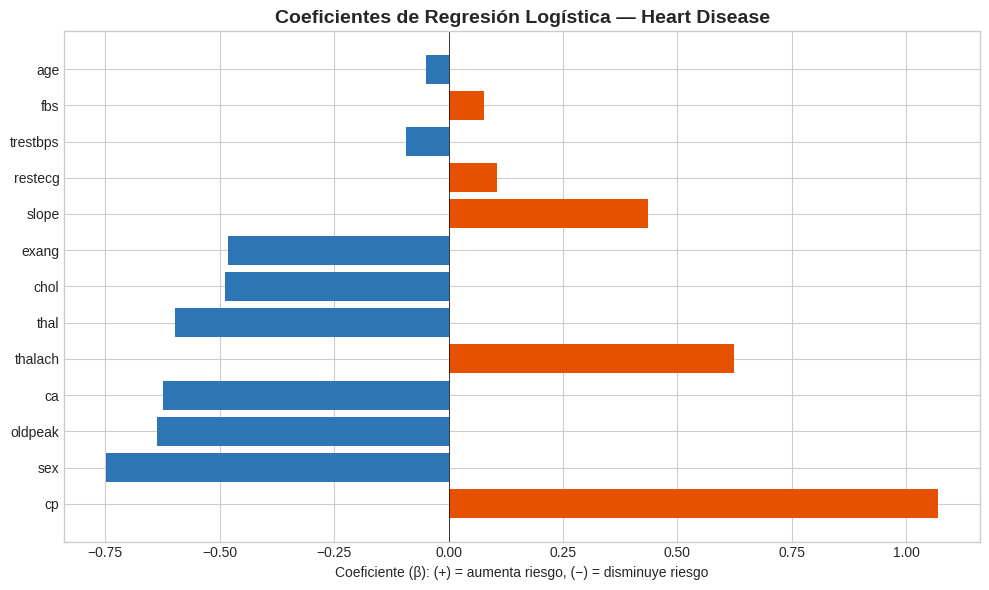

In [ ]:
# Entrenar Regresión Logística
lr = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

print('=' * 55)
print('REGRESIÓN LOGÍSTICA — EVALUACIÓN EN TEST SET')
print('=' * 55)
print(classification_report(y_test, y_pred_lr, target_names=['Sano (0)', 'Enfermo (1)']))

auc_lr = roc_auc_score(y_test, y_prob_lr)
gini_lr = 2 * auc_lr - 1
print(f'AUC-ROC: {auc_lr:.4f}')
print(f'Gini:    {gini_lr:.4f}')

# ==========================================
# COEFICIENTES Y ODDS RATIOS
# ==========================================
print('\n' + '=' * 70)
print('COEFICIENTES E INTERPRETACIÓN CLÍNICA')
print('=' * 70)
print(f'{"Variable":>12s}  {"β":>9s}  {"OR":>8s}  Interpretación clínica')
print('-' * 70)

coefs = pd.DataFrame({'Variable': X.columns, 'Coeficiente': lr.coef_[0],
                       'Odds_Ratio': np.exp(lr.coef_[0])})
coefs = coefs.sort_values('Coeficiente', key=abs, ascending=False)

for _, row in coefs.iterrows():
    var = row['Variable']
    beta = row['Coeficiente']
    odds = row['Odds_Ratio']
    if beta > 0.1:
        interp = f'⬆️ AUMENTA riesgo (OR={odds:.2f})'
    elif beta < -0.1:
        interp = f'⬇️ DISMINUYE riesgo (OR={odds:.2f})'
    else:
        interp = f'↔️ Efecto pequeño (OR={odds:.2f})'
    print(f'{var:>12s}  {beta:+9.4f}  {odds:8.4f}  {interp}')

# Gráfico de coeficientes
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#E65100' if v > 0 else '#2E75B6' for v in coefs['Coeficiente']]
bars = ax.barh(coefs['Variable'], coefs['Coeficiente'], color=colors)
ax.set_title('Coeficientes de Regresión Logística — Heart Disease',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Coeficiente (β): (+) = aumenta riesgo, (−) = disminuye riesgo')
ax.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

### ✏️ **Pregunta 6**
**¿Cuáles son las 3 variables con mayor coeficiente (en valor absoluto)? Clasifícalas: ¿cuáles AUMENTAN el riesgo (OR > 1) y cuáles lo DISMINUYEN (OR < 1)?**

***Respuesta:***

*Las 3 variables con mayor coeficiente absoluto son `cp`, `sex` y `oldpeak`.*

* *`cp` (`β = +1.0700`, `OR = 2.9154`): `OR > 1` → **aumenta** el riesgo. Valores más altos de tipo de dolor torácico se asocian a casi 3 veces más probabilidad de enfermedad, lo cual tiene sentido clínico si la codificación refleja mayor gravedad.*

* *`sex` (`β = -0.7485`, `OR = 0.4731`) y `oldpeak` (`β = -0.6375`, `OR = 0.5286`): ambas con `OR < 1` → **disminuyen** el riesgo. Esto es contraintuitivo: en la codificación del dataset, `sex=1` (masculino) se asocia a menor riesgo que `sex=0` (femenino), y mayor depresión del segmento ST (`oldpeak`) también se relaciona con menor probabilidad de enfermedad, cuando clínicamente ambos suelen ser indicadores de mayor riesgo.*

### ✏️ **Pregunta 7**
**Si la variable `sex` tiene Odds Ratio = 1.8, escribe exactamente cómo se lo explicarías a un médico que no sabe estadística. Recuerda: `sex=1` es masculino, `sex=0` es femenino.**

***Respuesta:***

*"Doctor/a, si el modelo indica que la variable `sex` tiene un `Odds Ratio` de `1.8`, esto significa que: comparando un hombre (`sex=1`) con una mujer (`sex=0`) que tengan la misma edad, colesterol y demás características, los hombres tienen `1.8` veces más probabilidades de presentar enfermedad cardíaca.*

*En términos prácticos: ser hombre aumenta un `80%` las chances de tener la enfermedad, comparado con ser mujer, manteniendo todo lo demás constante. No es una regla absoluta para cada paciente, sino una tendencia promedio que observamos en los datos."*

---
## 🔹 **Paso 7: Comparación k-NN vs. Regresión Logística**

### **¿Por qué comparar?**
Ambos modelos resuelven el mismo problema pero de formas muy diferentes:

| Aspecto | k-NN (Lazy Learner) | Reg. Logística (Eager Learner) |
|---|---|---|
| **Entrenamiento** | No entrena, memoriza los datos | Aprende coeficientes β durante entrenamiento |
| **Predicción** | Lento: calcula distancias con TODOS los puntos | Rápido: solo aplica la fórmula σ(βX) |
| **Interpretabilidad** | Baja: no explica POR QUÉ clasifica | Alta: coeficientes y OR dan explicaciones |
| **Fronteras** | Complejas, no lineales | Lineales (separación recta) |
| **Normalización** | OBLIGATORIA | Recomendada |

*Ref: Burkov, A. (2019). The Hundred-Page Machine Learning Book. Cap. 3.*

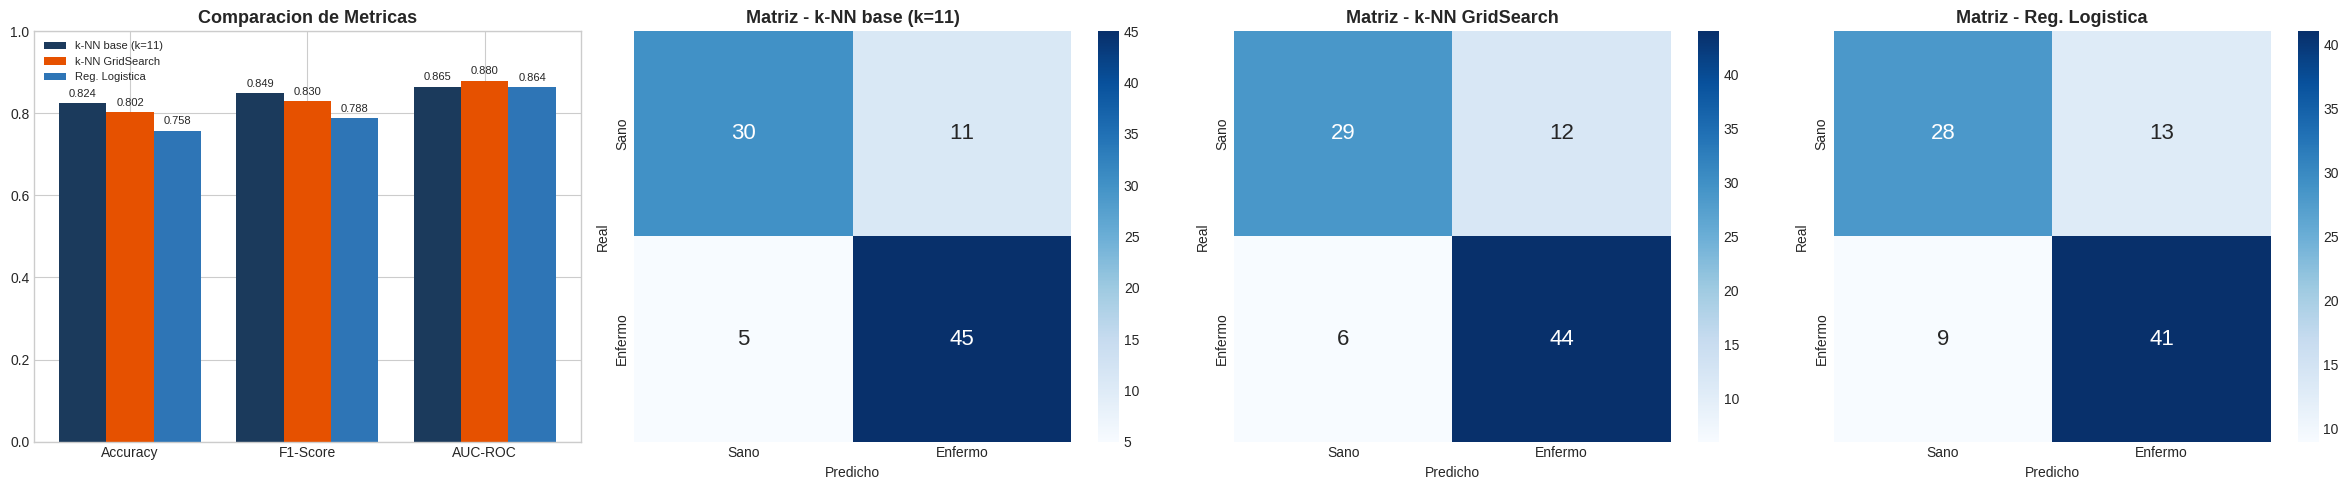


RESUMEN COMPARATIVO
                Modelo   Accuracy       F1   Recall      AUC    FN
------------------------------------------------------------------------------
      k-NN base (k=11)     0.8242   0.8491   0.9000   0.8654     5
       k-NN GridSearch     0.8022   0.8302   0.8800   0.8798     6
        Reg. Logistica     0.7582   0.7885   0.8200   0.8639     9


In [ ]:
# ==========================================
# COMPARACION VISUAL COMPLETA
# ==========================================
models = {
    f'k-NN base (k={best_k})': (y_pred_knn, y_prob_knn),
    'k-NN GridSearch': (y_pred_knn_grid, y_prob_knn_grid),
    'Reg. Logistica': (y_pred_lr, y_prob_lr)
}

fig, axes = plt.subplots(1, len(models) + 1, figsize=(6 * (len(models) + 1), 5))

# 1. Barras de metricas
metrics_data = {}
for name, (pred, prob) in models.items():
    metrics_data[name] = {
        'Accuracy': accuracy_score(y_test, pred),
        'F1-Score': f1_score(y_test, pred),
        'AUC-ROC': roc_auc_score(y_test, prob)
    }

metric_names = ['Accuracy', 'F1-Score', 'AUC-ROC']
x = np.arange(len(metric_names))
width = 0.8 / len(models)
colors = ['#1B3A5C', '#E65100', '#2E75B6']

for idx, (name, values) in enumerate(metrics_data.items()):
    offset = (idx - (len(models) - 1) / 2) * width
    bars = axes[0].bar(x + offset, [values[m] for m in metric_names],
                       width, label=name, color=colors[idx % len(colors)])
    axes[0].bar_label(bars, fmt='%.3f', padding=3, fontsize=8)

axes[0].set_xticks(x)
axes[0].set_xticklabels(metric_names)
axes[0].set_ylim(0, 1)
axes[0].set_title('Comparacion de Metricas', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=8)

# Matrices de confusion
for i, (name, (pred, _)) in enumerate(models.items(), start=1):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Sano', 'Enfermo'], yticklabels=['Sano', 'Enfermo'],
                annot_kws={'size': 16})
    axes[i].set_title(f'Matriz - {name}', fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Predicho')
    axes[i].set_ylabel('Real')

plt.tight_layout()
plt.show()

# Tabla resumen
print('\n' + '=' * 78)
print('RESUMEN COMPARATIVO')
print('=' * 78)
print(f'{"Modelo":>22s}  {"Accuracy":>9s}  {"F1":>7s}  {"Recall":>7s}  {"AUC":>7s}  {"FN":>4s}')
print('-' * 78)
for name, (pred, prob) in models.items():
    a = roc_auc_score(y_test, prob)
    cm = confusion_matrix(y_test, pred)
    print(f'{name:>22s}  {accuracy_score(y_test,pred):9.4f}  {f1_score(y_test,pred):7.4f}  '
          f'{recall_score(y_test,pred):7.4f}  {a:7.4f}  {cm[1,0]:4d}')


### ✏️ **Pregunta 8**
**¿Qué modelo tiene mejor F1-Score? ¿Y mejor AUC-ROC? Si las métricas no coinciden en señalar al mismo ganador, ¿cuál priorizarías para un diagnóstico médico y por qué?**

***Respuesta:***

*El modelo con mejor `F1-Score` para la clase 'Enfermo' es el `k-NN` base (`k=11`) con `0.85`. El modelo con mejor `AUC-ROC` es el `k-NN` con GridSearch con `0.8798`. Las métricas no coinciden en el ganador.*

*Para un diagnóstico médico, priorizaría el `F1-Score`. Esta métrica equilibra `Precisión` y `Recall` para la clase positiva ('Enfermo'), lo cual es clave en salud: un alto `Recall` reduce Falsos Negativos (pacientes enfermos que quedan sin tratamiento), mientras que una buena `Precisión` limita Falsos Positivos (estudios innecesarios en pacientes sanos). En enfermedad cardíaca, las consecuencias de un Falso Negativo suelen ser más graves, por lo que el balance que ofrece el `F1-Score` es más relevante para la decisión clínica.*

*El `AUC-ROC` mide la capacidad de discriminación del modelo en todos los umbrales posibles, lo que es útil para evaluar rendimiento global. Sin embargo, en la práctica clínica se trabaja con un umbral fijo (ej. `0.5`), y el `F1-Score` refleja directamente el desempeño en ese punto operativo, alineándose mejor con el objetivo de minimizar errores de alto impacto.*

### ✏️ **Pregunta 9**
**Compara los Falsos Negativos de ambos modelos (cuadrante inferior izquierdo de cada matriz). ¿Qué modelo tiene MENOS FN? ¿Por qué esto es lo MÁS IMPORTANTE en diagnóstico médico? (Pista: un FN = un paciente enfermo que se va sin tratamiento)**

***Respuesta:***

*Comparando los Falsos Negativos: `k-NN` base (`k=11`) tiene `5 FN`, `k-NN` GridSearch tiene `6 FN`, y Regresión Logística tiene `9 FN`. El modelo con menos `FN` es el `k-NN` base.*

*En diagnóstico médico, minimizar los `FN` es prioritario porque un Falso Negativo significa que un paciente enfermo recibe un diagnóstico de "sano" y queda sin tratamiento. Esto puede llevar a empeoramiento de la condición, pérdida de la ventana para intervención temprana, y consecuencias clínicas graves o fatales.*

*Desde una perspectiva ética, es preferible un Falso Positivo (paciente sano derivado a estudios adicionales) que un `FN`. Por eso, en aplicaciones médicas se suele ajustar el modelo para maximizar el `Recall` (minimizar `FN`), incluso si esto implica sacrificar ligeramente la `Precisión`.*

---
## 🔹 **Paso 8: Curvas ROC comparativas**

### **¿Qué es la curva ROC?**
Grafica la tasa de verdaderos positivos (TPR) contra la tasa de falsos positivos (FPR) para todos los umbrales posibles.
- **Cuanto más arriba y a la izquierda** la curva, mejor es el modelo.
- **La diagonal gris** representa un clasificador aleatorio (lanzar una moneda).
- **AUC** = área bajo la curva. AUC > 0.8 = modelo bueno.

*Ref: James, G. et al. (2023). An Introduction to Statistical Learning. Cap. 4.*

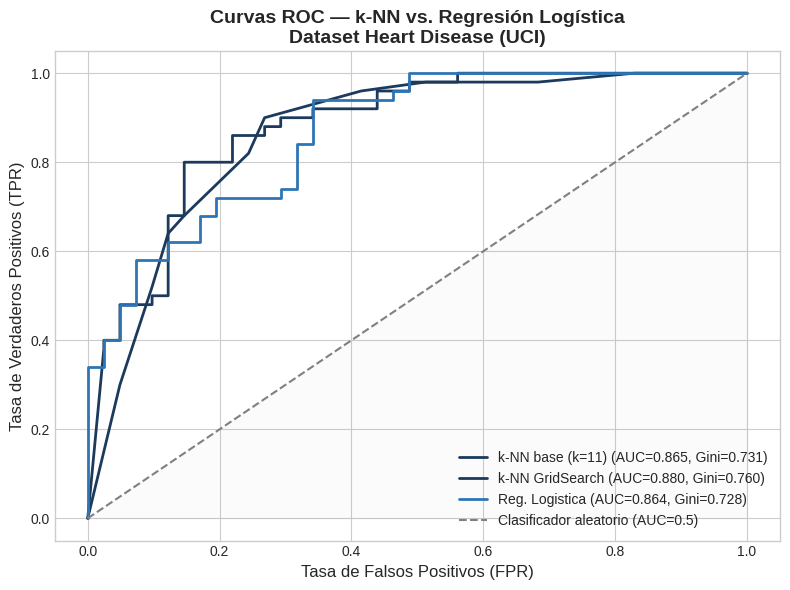


RESUMEN FINAL — HEART DISEASE CLASSIFICATION

📊 k-NN base (k=11):
   Accuracy:  0.8242
   F1-Score:  0.8491
   Precision: 0.8036
   Recall:    0.9000
   AUC-ROC:   0.8654
   Gini:      0.7307

📊 k-NN GridSearch:
   Accuracy:  0.8022
   F1-Score:  0.8302
   Precision: 0.7857
   Recall:    0.8800
   AUC-ROC:   0.8798
   Gini:      0.7595

📊 Reg. Logistica:
   Accuracy:  0.7582
   F1-Score:  0.7885
   Precision: 0.7593
   Recall:    0.8200
   AUC-ROC:   0.8639
   Gini:      0.7278


In [ ]:
# Curvas ROC comparativas
fig, ax = plt.subplots(figsize=(8, 6))

for name, (_, prob) in models.items():
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc_val = roc_auc_score(y_test, prob)
    gini_val = 2 * auc_val - 1
    color = '#1B3A5C' if 'k-NN' in name else '#2E75B6'
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f'{name} (AUC={auc_val:.3f}, Gini={gini_val:.3f})')

ax.plot([0,1],[0,1], color='gray', linestyle='--', label='Clasificador aleatorio (AUC=0.5)')
ax.fill_between([0,1],[0,1], alpha=0.03, color='gray')
ax.set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=12)
ax.set_title('Curvas ROC — k-NN vs. Regresión Logística\nDataset Heart Disease (UCI)',
             fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.show()

# Resumen final
print('\n' + '=' * 60)
print('RESUMEN FINAL — HEART DISEASE CLASSIFICATION')
print('=' * 60)
for name, (pred, prob) in models.items():
    a = roc_auc_score(y_test, prob)
    print(f'\n📊 {name}:')
    print(f'   Accuracy:  {accuracy_score(y_test, pred):.4f}')
    print(f'   F1-Score:  {f1_score(y_test, pred):.4f}')
    print(f'   Precision: {precision_score(y_test, pred):.4f}')
    print(f'   Recall:    {recall_score(y_test, pred):.4f}')
    print(f'   AUC-ROC:   {a:.4f}')
    print(f'   Gini:      {2*a-1:.4f}')

### ✏️ **Pregunta 10**
**Observando las curvas ROC: ¿qué modelo domina al otro en todos los umbrales? ¿Se cruzan las curvas en algún punto? Basándote en TODO lo analizado (métricas, interpretabilidad, FN), ¿cuál recomendarías al hospital?**

***Respuesta:***

*La curva del `k-NN` GridSearch se ubica más arriba en general, reflejando su mayor `AUC-ROC` (`0.8798`), lo que indica mejor discriminación global. Las curvas del `k-NN` base y `Regresión Logística` se cruzan en algunos puntos, lo que significa que su rendimiento relativo depende del umbral de clasificación elegido.*

*Para el hospital, recomendaría el `k-NN` base (`k=11`). Aunque el `k-NN` GridSearch tiene mejor `AUC-ROC`, el modelo base obtuvo el mejor `F1-Score` para la clase 'Enfermo' (`0.8491`) y, lo más crítico, la menor cantidad de Falsos Negativos (`5 FN`). En diagnóstico médico, minimizar `FN` es prioritario porque representa pacientes enfermos que quedarían sin tratamiento.*

*Respecto a interpretabilidad, la `Regresión Logística` ofrece ventaja al proporcionar coeficientes y `Odds Ratios` explicables. Sin embargo, dado que el objetivo principal es detectar enfermedad con el menor riesgo de errores graves, el balance de métricas y seguridad clínica del `k-NN` base lo hace la opción más adecuada para este contexto.*

---
# **ACTIVIDAD 3: Caso de Estudio — Selección del Modelo para Diagnóstico Cardíaco**

> **Contexto:** Un hospital quiere implementar un sistema de apoyo al diagnóstico de enfermedad cardíaca. El comité médico necesita tu recomendación técnica: ¿k-NN o Regresión Logística? Debes justificar tu decisión considerando rendimiento, interpretabilidad y el impacto clínico de los errores.

### ✏️ **Pregunta A**
**¿Qué modelo recomendarías al hospital? Estructura tu respuesta en 3 ejes: (1) rendimiento (F1, AUC), (2) interpretabilidad para médicos (¿pueden entender por qué el modelo predice X?), (3) costo de cada tipo de error (FP = sano diagnosticado como enfermo → ansiedad y exámenes innecesarios; FN = enfermo no detectado → riesgo de muerte).**

***Respuesta:***

*Recomendaría al hospital el modelo `k-NN` base (`k=11`).*

* *(1) Rendimiento:* *El `k-NN` base obtuvo el mejor `F1-Score` para la clase 'Enfermo' (`0.8491`), superando a `Regresión Logística` (`0.7885`) y a `k-NN` GridSearch (`0.8302`). Aunque el `AUC-ROC` fue ligeramente mayor en GridSearch (`0.8798` vs `0.8654`), el `F1-Score` es más relevante en este contexto porque evalúa el equilibrio entre `Precisión` y `Recall` en el umbral operativo (`0.5`), que es donde se toma la decisión clínica.*

* *(2) Interpretabilidad:* *La `Regresión Logística` tiene ventaja aquí: sus coeficientes (`β`) y `Odds Ratios` permiten explicar a un médico cómo cada variable influye en el riesgo (ej. "`OR = 2` significa el doble de probabilidad"). El `k-NN` es menos transparente, pero su lógica ("decidir según pacientes similares") es intuitiva y puede complementarse con análisis de casos representativos para facilitar la comprensión clínica.*

* *(3) Costo de errores:* *El `k-NN` base registró la menor cantidad de Falsos Negativos (`5 FN`), el error más crítico en diagnóstico médico: un paciente enfermo que se va sin tratamiento. Los Falsos Positivos (`FP`) generan ansiedad y estudios adicionales, pero su impacto es menor comparado con el riesgo de un `FN`. Por eso, priorizar un modelo con menos `FN` —aunque sacrifique ligeramente interpretabilidad— es la decisión más alineada con la seguridad del paciente.*

### ✏️ **Pregunta B**
**El médico jefe pregunta: '¿Qué factores de riesgo son los más importantes para la enfermedad cardíaca?' ¿Puedes responder esta pregunta con k-NN? ¿Y con Regresión Logística? Explica por qué uno de los dos modelos permite responder y el otro no.**

**Respuesta:**

**Con k-NN (k-Nearest Neighbors):**

No, con `k-NN` no podemos responder directamente qué factores de riesgo son los más importantes. El `k-NN` es un algoritmo "lazy learner" (aprendizaje perezoso) basado en la similitud: clasifica un nuevo punto basándose en la etiqueta de sus `k` vecinos más cercanos en el espacio de características. No aprende pesos o coeficientes para las variables ni construye un modelo explícito que relacione las características con el resultado. Por lo tanto, no hay una forma directa de extraer la "importancia" de las variables individuales a partir de un modelo `k-NN` entrenado.

**Con Regresión Logística:**

Sí, con la `Regresión Logística` podemos responder directamente qué factores de riesgo son los más importantes. Este modelo calcula **coeficientes (β)** para cada variable predictora. La magnitud (valor absoluto) y el signo de estos coeficientes nos indican:

*   **Magnitud:** Cuanto mayor sea el valor absoluto de un coeficiente, más fuerte es la influencia de esa variable en la probabilidad de enfermedad.
*   **Signo:** Un coeficiente positivo (β > 0, o `Odds Ratio > 1`) indica que a medida que la variable aumenta, el riesgo de enfermedad también aumenta. Un coeficiente negativo (β < 0, o `Odds Ratio < 1`) indica que a medida que la variable aumenta, el riesgo de enfermedad disminuye.

Los `Odds Ratios (OR)`, que son la exponencial de los coeficientes, son especialmente útiles para una interpretación intuitiva. Por ejemplo, si `cp` tiene un `OR = 2.92`, significa que los pacientes con un tipo de dolor torácico más "alto" (según la codificación) tienen casi 3 veces más probabilidades de tener enfermedad cardíaca.

**¿Por qué uno permite responder y el otro no?**

La diferencia radica en su **transparencia y mecanismo de funcionamiento**:

*   La **Regresión Logística** es un modelo **lineal interpretable**. Aprende una función lineal (una ecuación) que relaciona las características de entrada con el log-odds de la variable objetivo. Los coeficientes de esta ecuación son las "pesos" que el modelo asigna a cada característica, cuantificando su importancia y dirección de influencia. Es un "eager learner" (aprendizaje ansioso) porque construye un modelo explícito durante el entrenamiento.

*   El **k-NN** es un modelo **no paramétrico y de caja negra**. No aprende ningún parámetro global para las características. En su lugar, el "conocimiento" del modelo reside en todo el conjunto de datos de entrenamiento. La clasificación se realiza localmente en el momento de la predicción, basándose solo en los vecinos más cercanos. Por lo tanto, no genera un resumen global de la importancia de las variables. Aunque se podrían realizar análisis indirectos (como la eliminación recursiva de características), no es una propiedad intrínseca del modelo como lo son los coeficientes de la Regresión Logística.

### ✏️ **Pregunta C**
**En diagnóstico médico, ¿es peor un Falso Positivo (decirle a un sano que está enfermo) o un Falso Negativo (no detectar a un enfermo)? Si quisieras reducir los FN a costa de aumentar los FP, ¿qué parámetro del modelo ajustarías? (Pista: el umbral de clasificación, por defecto 0.5)**

***Respuesta:***

*En diagnóstico médico, generalmente **es peor un Falso Negativo (`FN`)** que un Falso Positivo (`FP`).*

* *`FN`: el modelo predice "sano" cuando el paciente está "enfermo". Las consecuencias pueden ser graves: sin tratamiento, la condición empeora, aumenta el riesgo de muerte y se pierde la oportunidad de intervención temprana. La implicación ética y clínica de un `FN` es muy alta.*

* *`FP`: el modelo predice "enfermo" cuando el paciente está "sano". Las consecuencias suelen ser menos graves: ansiedad, pruebas adicionales (costosas o invasivas) y uso ineficiente de recursos. No es deseable, pero el impacto es menor comparado con un `FN`.*

*Si quisiéramos reducir los `FN` a costa de aumentar los `FP`, ajustaríamos el **umbral de clasificación**.*

*Los modelos probabilísticos (como `Regresión Logística`) no predicen directamente `0` o `1`, sino una probabilidad de pertenecer a la clase positiva. Por defecto, si `probabilidad > 0.5` → se clasifica como "enfermo"; si `<= 0.5` → "sano".*

*Para reducir los `FN`: se debe **disminuir el umbral** (ej. de `0.5` a `0.3`). Al bajar el umbral, el modelo se vuelve más sensible: una probabilidad de `0.3` (que antes se clasificaba como "sano") ahora se clasifica como "enfermo". Esto detecta más enfermos reales (menos `FN`), pero inevitablemente aumenta los `FP` (más sanos clasificados erróneamente).*

### ✏️ **Pregunta D**
**Compara los dos datasets que hemos usado en el curso: `Heart Disease` (303 pacientes, 13 variables numéricas) vs. `Telco Churn` (7,043 clientes, variables mixtas). ¿En cuál de los dos `k-NN` tiene más desventaja computacional? ¿Por qué `Heart Disease` no necesitó `One-Hot Encoding` mientras que `Telco Churn` sí?**

***Respuesta:***
*1. ¿En cuál de los dos `k-NN` tiene más desventaja computacional?*

*El algoritmo `k-NN` tendrá una desventaja computacional mucho mayor en el dataset `Telco Churn`.*

*Razón: `k-NN` es un *lazy learner* que no entrena un modelo explícito, sino que memoriza todos los datos de entrenamiento. Para predecir, calcula la distancia de un nuevo punto a **todos** los puntos del conjunto de entrenamiento. La complejidad es aproximadamente `O(N * D)`, donde `N` = número de muestras y `D` = número de características.*
* *`Heart Disease`: `N = 303` pacientes.*
* *`Telco Churn`: `N = 7,043` clientes (~23 veces más).*

*Aunque `Telco Churn` tiene variables mixtas que, tras `One-Hot Encoding`, pueden aumentar `D`, la diferencia en `N` es el factor dominante. Esto hace que las predicciones de `k-NN` sean mucho más lentas y costosas en `Telco Churn`.*

*2. ¿Por qué `Heart Disease` no necesitó `One-Hot Encoding` mientras que `Telco Churn` sí?*

*La diferencia radica en la naturaleza de las variables categóricas y su codificación original:*

*`Heart Disease`: Las variables categóricas (`sex`, `cp`, `fbs`, `restecg`, `exang`, `slope`, `ca`, `thal`) ya venían codificadas numéricamente en el dataset. Algunas son binarias (`0/1`), y otras son ordinales/nominales con mapeo numérico (ej. `cp: 0-3`, `slope: 0-2`). Como `k-NN` y `Regresión Logística` requieren entrada numérica, no fue necesario aplicar `One-Hot Encoding`; bastó con escalar las variables para que estuvieran en rangos comparables.*

*`Telco Churn`: Este dataset incluye variables categóricas nominales sin orden inherente (ej. `InternetService: 'DSL'/'Fiber optic'/'No'`, `Contract: 'Month-to-month'/'One year'/'Two year'`). Si se codificaran como números arbitrarios (`1, 2, 3`), el modelo interpretaría erróneamente una relación ordinal o de magnitud que no existe. Por eso se aplicó `One-Hot Encoding`: para transformar cada categoría en una columna binaria independiente (`0/1`), evitando que el modelo asuma jerarquías artificiales entre categorías.*

### ✏️ **Pregunta E**
**Propón 3 mejoras concretas y específicas para mejorar el rendimiento de los modelos en este dataset. Para cada mejora, explica qué problema resuelve. (Ejemplos: feature engineering clínico, regularización, `SMOTE`, selección de variables, ensembles, etc.)**

***Respuesta:***

*1. Feature Engineering Clínico Avanzado:*
*Mejora: Desarrollar nuevas características combinando conocimiento clínico con variables existentes. Ejemplos: crear variables de interacción (ej. `edad * sexo`), o categorizar variables continuas (`age`, `chol`, `trestbps`, `thalach`) en rangos clínicamente significativos (ej. "edad avanzada", "colesterol alto"). También investigar ratios o diferencias entre variables.*
*Problema que resuelve: Captura relaciones más complejas y no lineales que modelos como `k-NN` o `Regresión Logística` podrían no detectar. Puede ayudar a resolver correlaciones contraintuitivas observadas (`exang`, `oldpeak`, `sex`) si se representa su impacto clínico de forma más fiel. Mejora la interpretabilidad al alinear las características con conceptos médicos.*

*2. Modelos Ensemble (Bosques Aleatorios o Gradient Boosting):*
*Mejora: Emplear ensamblajes como `Random Forest` o `Gradient Boosting` (ej. `XGBoost`, `LightGBM`). Estos modelos construyen múltiples árboles de decisión y combinan sus predicciones.*
*Problema que resuelve: Reduce el sobreajuste (*overfitting*) y la varianza del modelo, resultando en mayor robustez y mejor generalización. Los modelos ensemble suelen superar el rendimiento de modelos individuales, lo que podría traducirse en mejor `F1-Score` y menos Falsos Negativos.*

*3. Tuning de Hiperparámetros con Optimización Bayesiana o Avanzada:*
*Mejora: En lugar de `GridSearch` exhaustivo, usar métodos más eficientes como Optimización Bayesiana o `RandomizedSearchCV`. Esto permite explorar el espacio de hiperparámetros de forma más inteligente para encontrar combinaciones óptimas (`k`, `weights`, `metric` para `k-NN`; `C`, `penalty` para `Regresión Logística`; hiperparámetros de ensembles).*
*Problema que resuelve: Permite encontrar configuraciones más óptimas que búsquedas manuales o `GridSearch` básicos, maximizando el rendimiento sin sobreajustar y minimizando tiempo de cómputo. Un ajuste fino es crucial para exprimir el máximo potencial de cualquier algoritmo.*

---
# 📝 **CONCLUSIONES**

*1. La selección del modelo en contextos críticos debe priorizar el coste de los errores:*
*En diagnóstico médico, la minimización de Falsos Negativos (pacientes enfermos no detectados) es fundamental, incluso si esto implica un ligero aumento de Falsos Positivos o una menor interpretabilidad del modelo. En este laboratorio, el `k-NN` base, con su mejor `F1-Score` y menor cantidad de `FN`, se consideró superior para la aplicación hospitalaria, a pesar de que la `Regresión Logística` ofrecía mayor interpretabilidad.*

*2. La preparación de datos y la sintonización de hiperparámetros son cruciales pero deben validarse con cautela:*
*La estandarización de las variables fue esencial para el `k-NN`. La búsqueda del `k` óptimo, tanto manual como con `GridSearch`, mostró que el rendimiento en validación cruzada no siempre se traduce directamente en un rendimiento superior en el conjunto de prueba, destacando la importancia de una evaluación final en datos no vistos y la posibilidad de que un ajuste excesivo lleve a un *overfitting* más sutil.*

*3. La interpretabilidad y el conocimiento del dominio son complementos indispensables al rendimiento métrico:*
*La `Regresión Logística`, al proporcionar `Odds Ratios` y coeficientes, permitió una interpretación directa de los factores de riesgo, invaluable para los profesionales médicos. Las correlaciones inicialmente contraintuitivas (`exang`, `oldpeak`, `sex`) en el análisis exploratorio y en la `Regresión Logística`, subrayan la necesidad de integrar el conocimiento experto del dominio para validar o cuestionar los hallazgos del modelo y guiar futuras mejoras (ej. `feature engineering` clínico).*

---
### 📚 **Referencias bibliográficas**
- Burkov, A. (2019). *The Hundred-Page Machine Learning Book*. Andriy Burkov.
- Géron, A. (2022). *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow* (3.ª ed.). O'Reilly Media.
- Gironés Roig, J., Casas Roma, J., Minguillón Alfonso, J. y Caihuelas Quiles, R. (2017). *Minería de datos: modelos y algoritmos*. Editorial UOC.
- James, G., Witten, D., Hastie, T. y Tibshirani, R. (2023). *An Introduction to Statistical Learning* (2.ª ed.). Springer.

---
*Minería de Datos — Semana 6 | TECSUP 2026-I | Prof. Pilar Rocío Sayán Mejía*